# 02. 이상 탐지 모델 학습 및 평가

MetroPT-3 데이터에서 정상 구간만으로 학습하는 unsupervised anomaly detection 파이프라인.

## 비교 모델
1. **IsolationForest** - 윈도우별 통계 특징 (mean/std/p2p/slope) 기반
2. **1D-CNN AutoEncoder** - 다변량 시계열 패턴 재구성 오차 기반

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_metropt3, make_windows, ANALOG_SENSORS
from src.models.anomaly import (
    IFAnomalyModel, IFConfig,
    AEAnomalyModel, AEConfig,
    find_best_threshold,
)

ARTIFACTS = PROJECT_ROOT / 'models_artifacts'
ARTIFACTS.mkdir(exist_ok=True)
print('imports OK')

imports OK


## 1. 데이터 로드 및 윈도우 생성

1분 평균으로 다운샘플된 데이터에서 60분 길이, stride 30분 슬라이딩 윈도우 생성.

In [ ]:
df = load_metropt3(data_dir=PROJECT_ROOT / 'data' / 'metropt3', downsample='1min')
print(f'data: {df.shape}, period: {df.index.min()} ~ {df.index.max()}')

WINDOW = 60
STRIDE = 30
X, y = make_windows(df, window=WINDOW, stride=STRIDE)
print(f'windows: X={X.shape}, y={y.shape}, fault_ratio={y.mean():.3f}')

data: (252720, 16), period: 2020-02-01 00:00:00 ~ 2020-09-01 03:59:00
windows: X=(8423, 60, 7), y=(8423,), fault_ratio=0.024


## 2. 시간순 train/test 분할 (timestamp 기반)

랜덤 분할은 시계열에서 데이터 누수를 일으키므로 시간순 분할 사용. 단순 인덱스 비율(예: 6:4)은 데이터 갭(누락 시간대) 때문에 캘린더 경계가 의도와 어긋남을 확인

본 데이터는 약 30일치 갭이 있어 60% 인덱스가 캘린더상 6월 중순으로 밀림

**타임스탬프 기준 분할**로 갭 영향 제거.

| 기간 | 포함된 fault |
|------|------------|
| Train: ~2020-05-25 | Air Leak #1 (4/12, 25개), Air Leak #2 (4/17~18, 50개) |
| Test: 2020-05-25~ | Air Leak #3 (5/29~30, 15개), Air Leak #4 (6/5~7, 97개), Oil Leak (7/15, 11개) |

test fault 약 **123개** (이전 11개 대비 11배). 학습된 정상 패턴과 분리되어 진정한 unseen-fault 평가가 가능.

In [ ]:
SPLIT_TIME = pd.Timestamp('2020-05-25')

window_starts = df.index[::STRIDE][:len(X)]
test_mask = window_starts >= SPLIT_TIME

X_train, y_train = X[~test_mask], y[~test_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

X_train_normal = X_train[y_train == 0]

print(f'split at: {SPLIT_TIME.date()}')
print(f'train: {X_train.shape} (normal {len(X_train_normal)}, fault {int(y_train.sum())})')
print(f'test:  {X_test.shape} (fault {int(y_test.sum())})')

split at: 2020-05-25
train: (4454, 60, 7) (normal 4379, fault 75)
test:  (3969, 60, 7) (fault 123)


## 3. IsolationForest 학습

In [4]:
if_model = IFAnomalyModel(IFConfig(n_estimators=200, contamination='auto'))
if_model.fit(X_train_normal)

scores_if = if_model.score(X_test)
thr_if, metrics_if = find_best_threshold(scores_if, y_test)
print(f'[IF] best_thr={thr_if:.4f}')
for k, v in metrics_if.items():
    print(f'    {k:10s} = {v:.4f}')

if_model.save(ARTIFACTS / 'iforest_v1.joblib')

[IF] best_thr=0.1570
    precision  = 0.4488
    recall     = 0.9268
    f1         = 0.6048
    pr_auc     = 0.3428


## 4. 1D-CNN AutoEncoder 학습

In [ ]:
ae_cfg = AEConfig(
    n_channels=len(ANALOG_SENSORS),
    hidden=32, latent=16,
    epochs=100, batch_size=128, lr=1e-3,
    per_window_norm=True,
)
print(f'device: {ae_cfg.device} | per_window_norm: {ae_cfg.per_window_norm}')
ae_model = AEAnomalyModel(ae_cfg)
ae_model.fit(X_train_normal)

scores_ae = ae_model.score(X_test)
thr_ae, metrics_ae = find_best_threshold(scores_ae, y_test)
print(f'\n[AE] best_thr={thr_ae:.4f}')
for k, v in metrics_ae.items():
    print(f'    {k:10s} = {v:.4f}')

ae_model.save(ARTIFACTS / 'convae_v1.pt')

device: cuda | per_window_norm: True
  epoch   1/100 | loss=0.7371
  epoch   5/100 | loss=0.1731
  epoch  10/100 | loss=0.0745
  epoch  15/100 | loss=0.0499
  epoch  20/100 | loss=0.0407
  epoch  25/100 | loss=0.0333
  epoch  30/100 | loss=0.0289
  epoch  35/100 | loss=0.0253
  epoch  40/100 | loss=0.0229
  epoch  45/100 | loss=0.0208
  epoch  50/100 | loss=0.0194
  epoch  55/100 | loss=0.0182
  epoch  60/100 | loss=0.0171
  epoch  65/100 | loss=0.0160
  epoch  70/100 | loss=0.0150
  epoch  75/100 | loss=0.0145
  epoch  80/100 | loss=0.0138
  epoch  85/100 | loss=0.0133
  epoch  90/100 | loss=0.0133
  epoch  95/100 | loss=0.0122
  epoch 100/100 | loss=0.0119

[AE] best_thr=0.0742
    precision  = 0.8112
    recall     = 0.9431
    f1         = 0.8722
    pr_auc     = 0.8796


## 5. 두 모델 비교 시각화

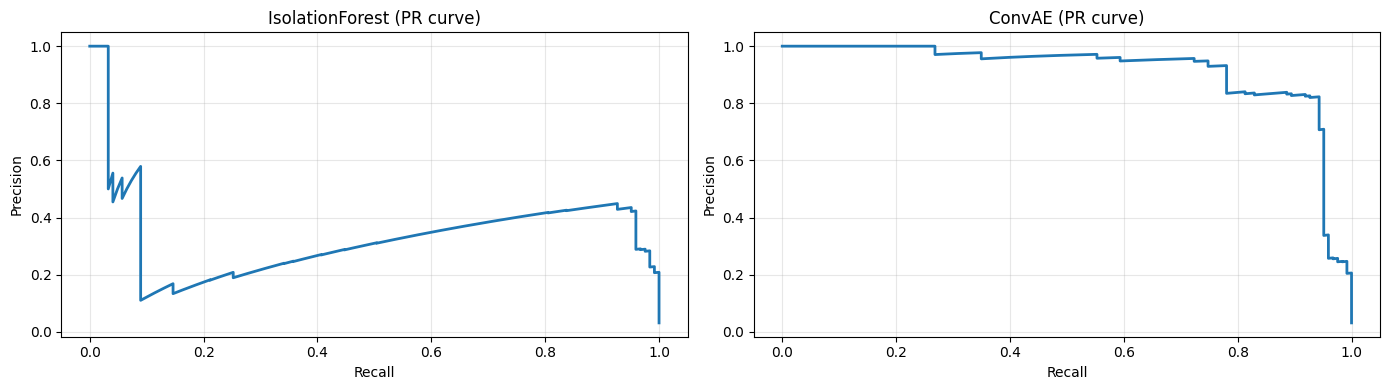

In [11]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, scores, thr) in zip(
    axes,
    [('IsolationForest', scores_if, thr_if), ('ConvAE', scores_ae, thr_ae)],
):
    p, r, _ = precision_recall_curve(y_test, scores)
    ax.plot(r, p, lw=2)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{name} (PR curve)')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

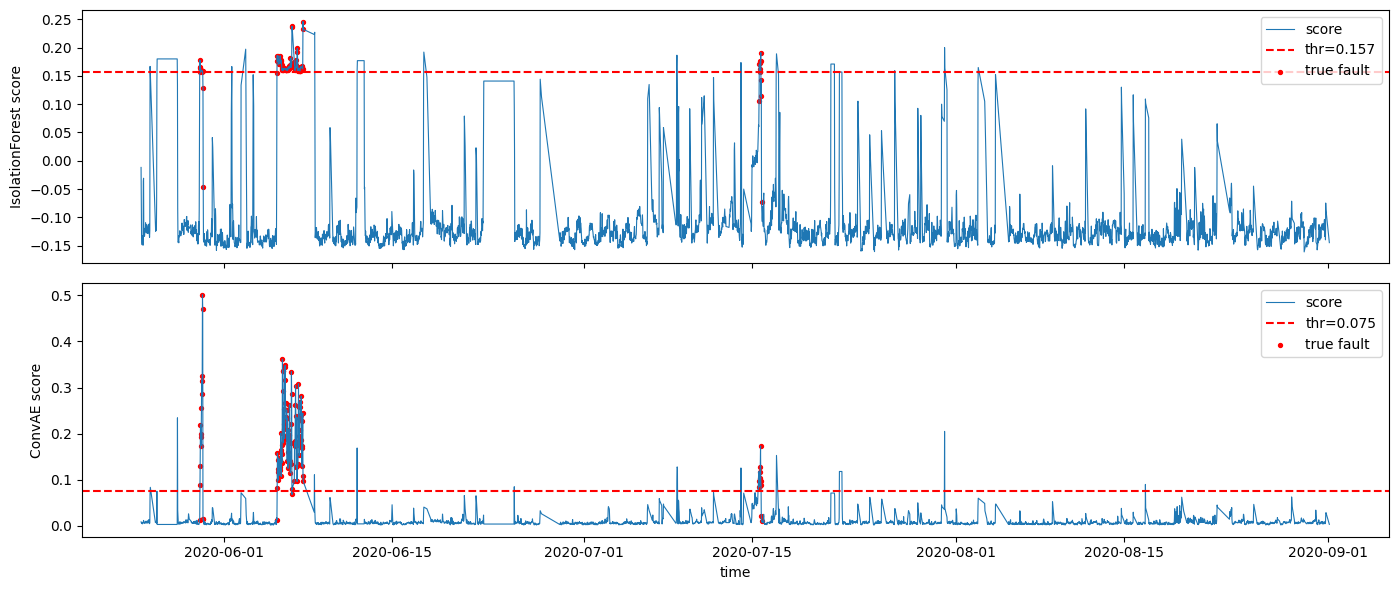

In [ ]:
test_times = window_starts[test_mask]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, (name, scores, thr) in zip(
    axes,
    [('IsolationForest', scores_if, thr_if), ('ConvAE', scores_ae, thr_ae)],
):
    ax.plot(test_times, scores, lw=0.8, label='score')
    ax.axhline(thr, color='r', ls='--', label=f'thr={thr:.3f}')
    fault_times = test_times[y_test == 1]
    if len(fault_times):
        ax.scatter(fault_times, scores[y_test == 1], s=8, c='red', label='true fault')
    ax.set_ylabel(f'{name} score')
    ax.legend(loc='upper right')
axes[-1].set_xlabel('time')
plt.tight_layout()
plt.show()

## 6. 메타데이터 저장

In [6]:
import json
meta = {
    'window': WINDOW,
    'stride': STRIDE,
    'sensors': ANALOG_SENSORS,
    'iforest': {'path': 'iforest_v1.joblib', 'threshold': thr_if, 'metrics': metrics_if},
    'convae':  {'path': 'convae_v1.pt',     'threshold': thr_ae, 'metrics': metrics_ae},
}
with open(ARTIFACTS / 'anomaly_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print('saved meta:', ARTIFACTS / 'anomaly_meta.json')

saved meta: d:\Work\study_full_data\log_anomaly_dectetion_pipeline\log-anomaly-detection\.claude\worktrees\epic-turing-62c439\llm_agent_phm\models_artifacts\anomaly_meta.json
